In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the historical stock price dataset
df = pd.read_csv('../data/raw/AAPL.csv')

# 2. Ensure Date is correctly typed and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# 3. Handle missing values (The most stable way for Pandas 2.0+)
df = df.ffill()

print("Step 1 Complete: Data loaded and cleaned.")
df.head()


Step 1 Complete: Data loaded and cleaned.


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
# 1. Moving Averages (20-day window)
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

# 2. RSI Calculation (14-day window)
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 3. MACD Calculation
exp12 = df['Close'].ewm(span=12, adjust=False).mean()
exp26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp12 - exp26
df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

print("Step 2 Complete: Technical indicators computed.")


Step 2 Complete: Technical indicators computed.


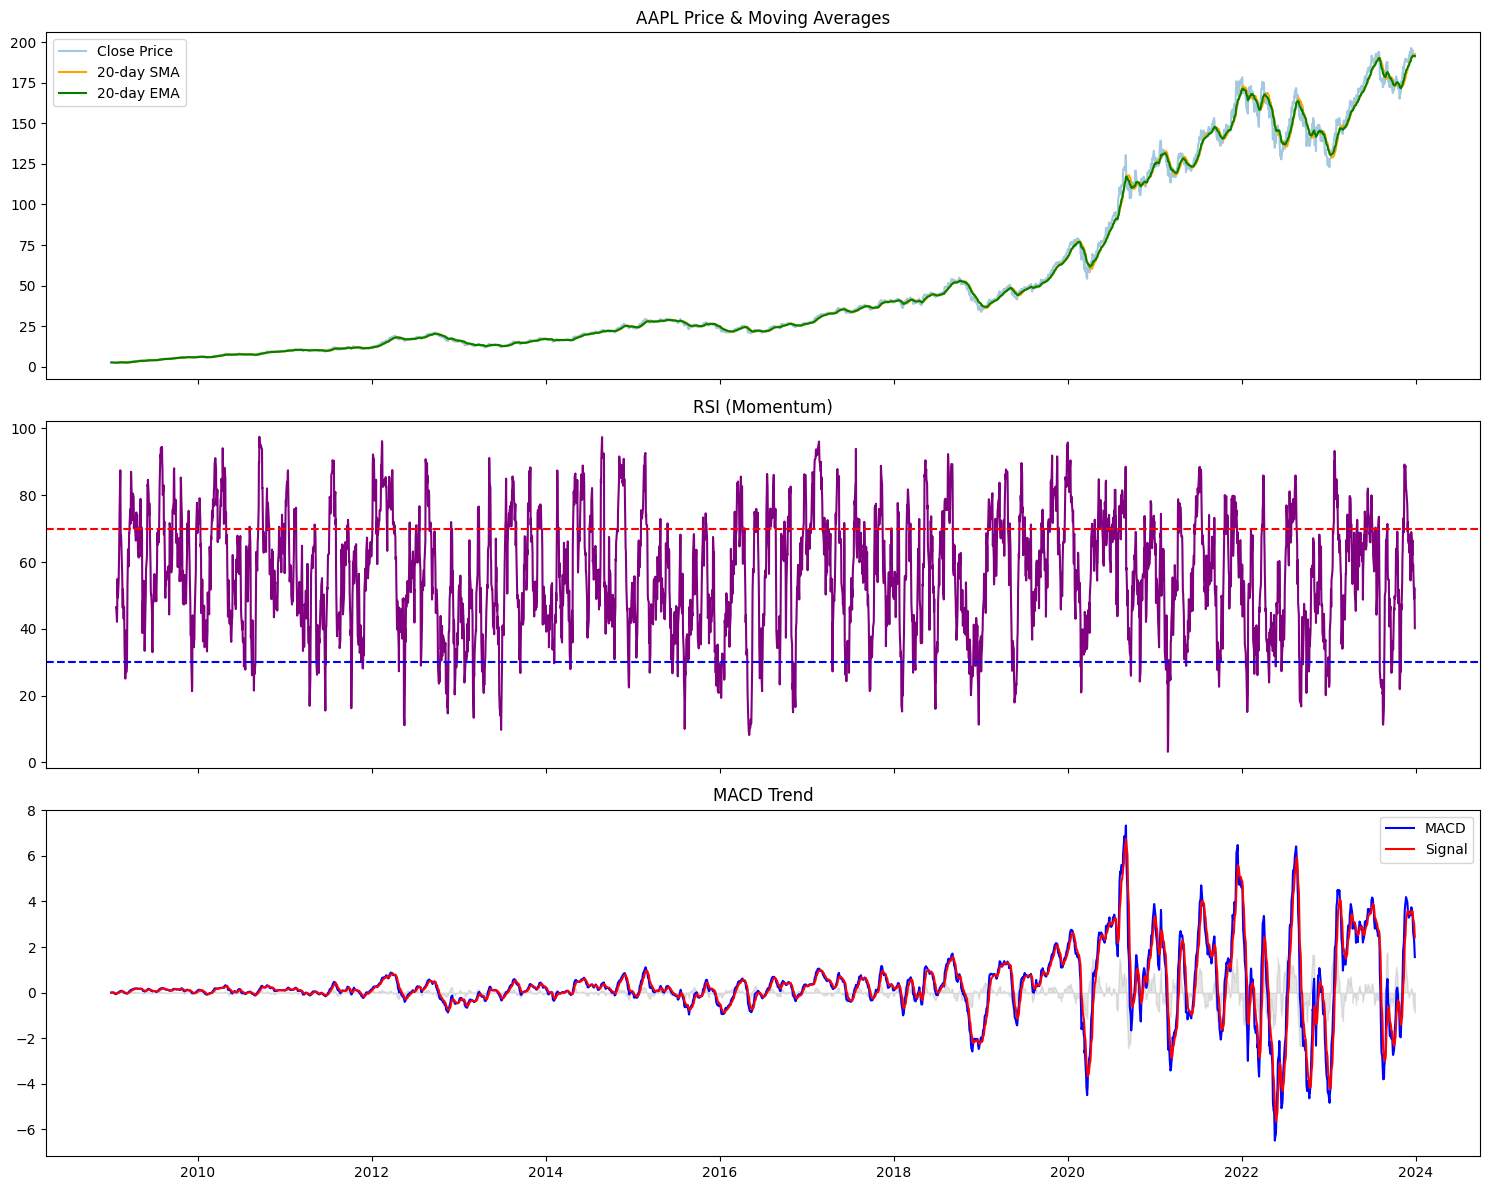

In [4]:
# Create a 3-panel chart
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Panel 1: Price and Moving Averages
ax1.plot(df['Close'], label='Close Price', alpha=0.4)
ax1.plot(df['SMA_20'], label='20-day SMA', color='orange')
ax1.plot(df['EMA_20'], label='20-day EMA', color='green')
ax1.set_title('AAPL Price & Moving Averages')
ax1.legend()

# Panel 2: RSI
ax2.plot(df['RSI'], color='purple')
ax2.axhline(70, color='red', linestyle='--') # Overbought
ax2.axhline(30, color='blue', linestyle='--') # Oversold
ax2.set_title('RSI (Momentum)')

# Panel 3: MACD
ax3.plot(df['MACD'], label='MACD', color='blue')
ax3.plot(df['Signal_Line'], label='Signal', color='red')
ax3.fill_between(df.index, df['MACD'] - df['Signal_Line'], color='gray', alpha=0.2)
ax3.set_title('MACD Trend')
ax3.legend()

plt.tight_layout()
plt.show()
